In [1]:
import os
import sys
import gc
os.chdir('/zhome/71/c/146676/texture_tomography')
import h5py, hdf5plugin
import numpy as np
from pathlib import Path

from package.texture_tomography.operators.pfo_single_material import PFO_SINGLE, estimate_L_power
from package.texture_tomography.operators.pfo_and_projection_batched_opencl import PFO_OPENCL_BATCHED

import matplotlib.pyplot as plt
from multiprocessing import Pool
import yaml


from package.texture_tomography.optimization.fista_opencl import FISTAOpenCL
from package.texture_tomography.optimization.fista_huber_opencl import FISTAHuberOpenCL
from package.texture_tomography.gpu_live_tracker import GPUMemoryLogger
from package.texture_tomography.operators.memory_tracker import MemoryCounter
import pyopencl.array as clarray
from package.texture_tomography.multiresolution_refiner import OrientationTree, invert_grid
from package.texture_tomography.material import Material
from scipy.spatial.transform import Rotation as R

from orix import plot, sampling
from orix.crystal_map import Phase
from orix.quaternion import Orientation, symmetry
from orix.vector import Vector3d
from sklearn.neighbors import KDTree


INFO:Setting the number of threads to 8. If your physical cores are fewer than this number, you may want to use numba.set_num_threads(n), and os.environ["OPENBLAS_NUM_THREADS"] = f"{n}" to set the number of threads to the number of physical cores n.
INFO:Setting numba log level to WARNING.


In [2]:
config_path = "configs/aluminum_config_single.yaml"

with open(config_path, 'r') as f:
    cfg = yaml.safe_load(f)

N_chi = cfg['N_chi']
N_rot = cfg['N_rot']
N_theta = cfg['N_theta']
Nx = cfg['Nx']
Ny = cfg['Ny']
datapath = cfg["datapath"]
filename_integrated = cfg["integrated_file"]
cif_path = cfg["cif_path"]
cor_offset = cfg["cor_offset"]
wavelength_kev = cfg['wavelength']
min_two_theta = cfg['min_two_theta']
max_two_theta = cfg['max_two_theta']
reflection_cutoff = cfg['reflection_cutoff']
filename = datapath + filename_integrated

In [3]:
with h5py.File(filename, "r") as f:
    dset = f["I"]
    arr = np.empty(dset.shape, dtype=dset.dtype)
    dset.read_direct(arr)

In [4]:
arr = arr/arr.sum(axis=(0,1,2), keepdims = True)*arr.sum()*10
all_data_reshaped1 = arr.reshape((3000, Nx, N_chi*N_theta))
all_data_reshaped = all_data_reshaped1[::3000//N_rot]/(3000//N_rot)

for i in range(1,3000//N_rot):
    all_data_reshaped += all_data_reshaped1[i::3000//N_rot]/(3000//N_rot)

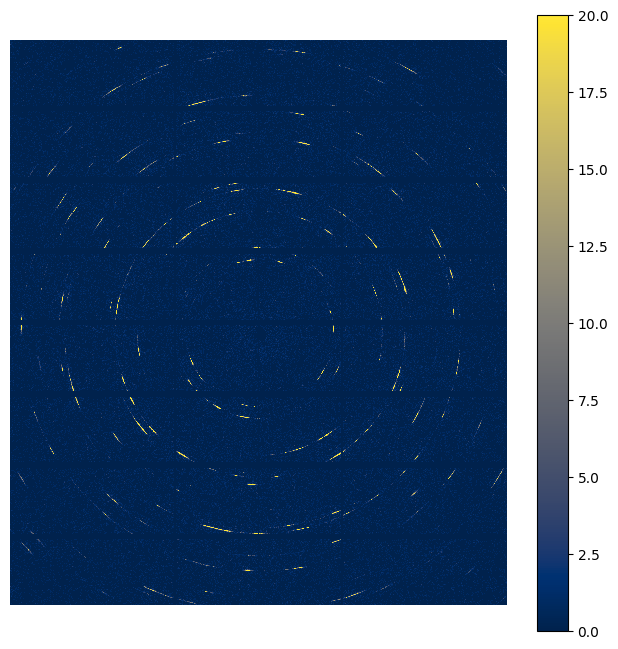

In [5]:
N_rot_raw = 3003
N_rot_use = N_rot_raw - 3
diffraction_files = cfg['diffraction_files']
i_h5 = 5
with h5py.File(datapath + diffraction_files[i_h5], 'r') as f:
    dataset = f['entry/instrument/pilatus/data']

    plt.figure(figsize=(8,8))
    plt.imshow(dataset[10000], cmap='cividis', interpolation='nearest')
    plt.colorbar()
    plt.clim([0,20])
    plt.axis('off')
    plt.savefig('/work3/msaca/presentation_plots/detector_image.png', bbox_inches = 'tight', dpi = 500)
    



In [6]:
import pyFAI
poni_path = cfg['poni_path']
ai = pyFAI.load(poni_path)
with h5py.File(datapath + diffraction_files[i_h5], 'r') as f:
    dataset = f['entry/instrument/pilatus/data']

    res = ai.integrate2d(
        dataset[10000],
        npt_rad=200,
        npt_azim=N_chi,
        radial_range=(0, 100),
        method=("no", "csr", "opencl"),
        )
    

INFO:No sensor configuration provided; using default behaviour.
INFO:Unable to parse `/dtu/3d-imaging-center/projects/2025_QIM_BlackBeauty/raw_data_extern/raw_data_aluminum_detector/LaB6_34p798keV_244p89mm.poni` as JSON file, defaulting to PoniParser
INFO:No sensor configuration provided; using default behaviour.
INFO:AI.integrate2d_ng: Resetting Cython integrator because of first initialization
INFO:AI.integrate2d: Resetting integrator because of first initialization
INFO:213.509MB are needed on device: Tesla V100-PCIE-16GB,  which has 16928.342MB
INFO:Compiling file ['silx:opencl/doubleword.cl', 'pyfai:openCL/preprocess.cl', 'pyfai:openCL/memset.cl', 'pyfai:openCL/ocl_azim_CSR.cl', 'pyfai:openCL/collective/reduction.cl', 'pyfai:openCL/collective/scan.cl', 'pyfai:openCL/collective/comb_sort.cl', 'pyfai:openCL/medfilt.cl'] with options -D NBINS=36000 -D NIMAGE=2476525


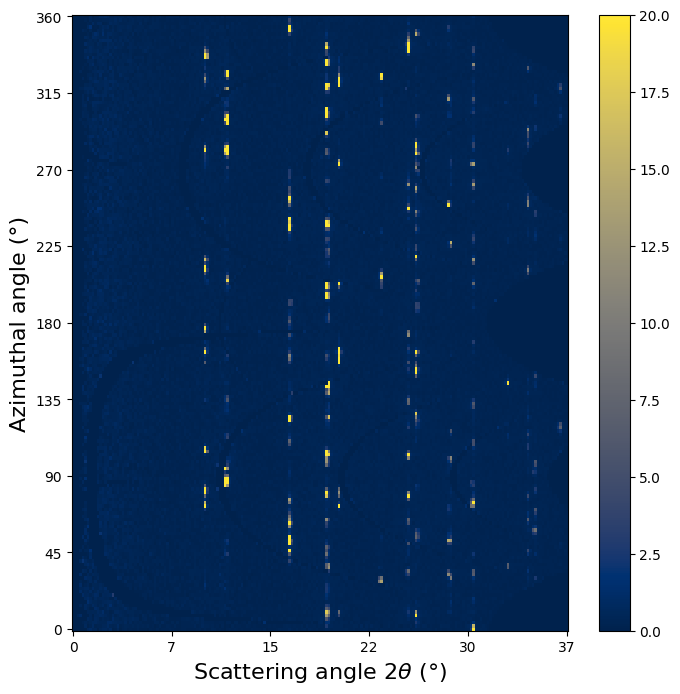

In [7]:
fig, ax = plt.subplots(figsize=(8, 8))

im = ax.imshow(
    res.intensity,
    interpolation='nearest',
    aspect='auto',
    cmap='cividis',
    origin='lower',   # important for angles
    vmin=0,
    vmax = 20
)

plt.colorbar(im, ax=ax)

# Axis labels
ax.set_ylabel(r'Azimuthal angle (°)', fontsize=16)
ax.set_xlabel(r'Scattering angle $2\theta$ (°)', fontsize=16)

# Y axis: 0 → 360 degrees
ny = res.intensity.shape[0]
ax.set_yticks(
    np.linspace(0, ny - 1, 9)
)
ax.set_yticklabels(
    [f"{int(v)}" for v in np.linspace(0, 360, 9)]
)

# X axis: 0 → 37 degrees
nx = res.intensity.shape[1]
ax.set_xticks(
    np.linspace(0, nx - 1, 6)
)
ax.set_xticklabels(
    [f"{v:.0f}" for v in np.linspace(0, 37, 6)]
)
plt.savefig('/work3/msaca/presentation_plots/detector_image_polar.png', bbox_inches = 'tight', dpi = 500)




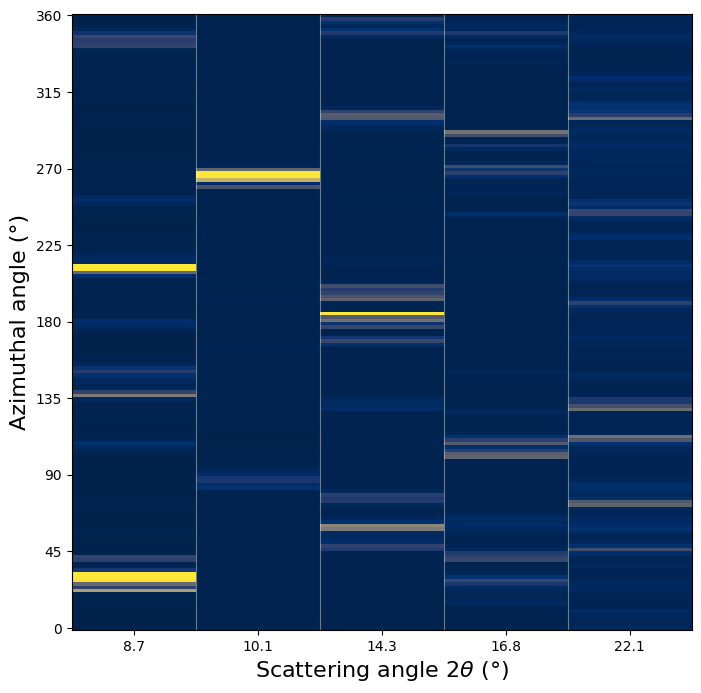

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# given scattering angles (radians)
theta_rad = np.array([0.15253486, 0.17618918, 0.24949357, 0.29284424, 0.3858888])
theta_deg = np.degrees(theta_rad)

data = all_data_reshaped.reshape((N_rot, Nx, N_chi, N_theta))

fig, ax = plt.subplots(figsize=(8, 8))

im = ax.imshow(
    data[0, 100],
    interpolation='nearest',
    aspect='auto',
    cmap='cividis',
    vmin=0,
    vmax=10000,
    origin='lower'
)
for x in np.arange(0.5, nx - 0.5, 1):
    ax.axvline(x, color='white', linewidth=0.8, alpha=0.4)


# Axis labels
ax.set_ylabel(r'Azimuthal angle (°)', fontsize=16)
ax.set_xlabel(r'Scattering angle $2\theta$ (°)', fontsize=16)

# ----- Y axis: 0 → 360 degrees -----
ny = data.shape[2]  # N_chi
ax.set_yticks(np.linspace(0, ny - 1, 9))
ax.set_yticklabels([f"{v:.0f}" for v in np.linspace(0, 360, 9)])

# ----- X axis: 5 columns with physical values -----
nx = data.shape[3]  # N_theta = 5
ax.set_xticks(np.arange(nx))
ax.set_xticklabels([f"{v:.1f}" for v in theta_deg])

plt.savefig(
    '/work3/msaca/presentation_plots/detector_rings.png',
    bbox_inches='tight',
    dpi=500
)



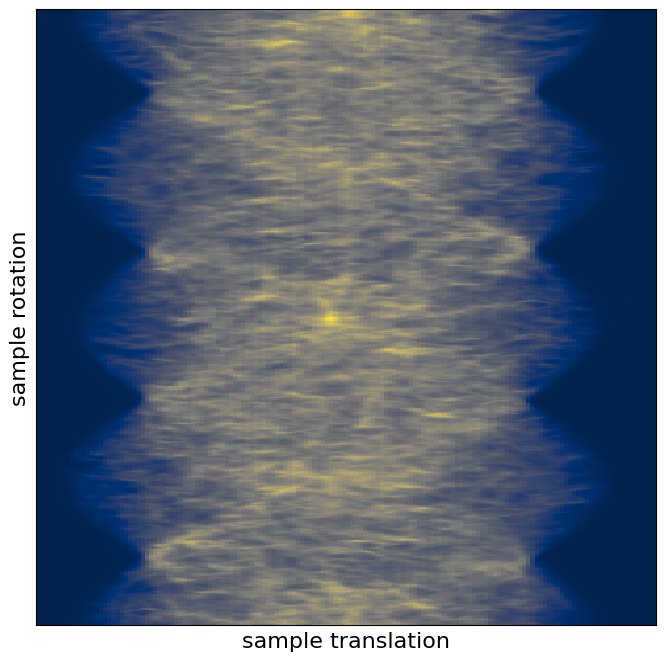

In [9]:
data = all_data_reshaped.reshape((N_rot, Nx, N_chi, N_theta))
plt.figure(figsize=(8,8))
plt.imshow(data.mean(axis=(2,3)), interpolation='nearest', aspect='auto', cmap='cividis')

ax = plt.gca()
ax.set_xticks([])
ax.set_yticks([])

ax.set_xlabel('sample translation', fontsize=16)
ax.set_ylabel('sample rotation', fontsize=16)
plt.savefig(
    '/work3/msaca/presentation_plots/sinogram_full_intensity.png',
    bbox_inches='tight',
    dpi=500
)

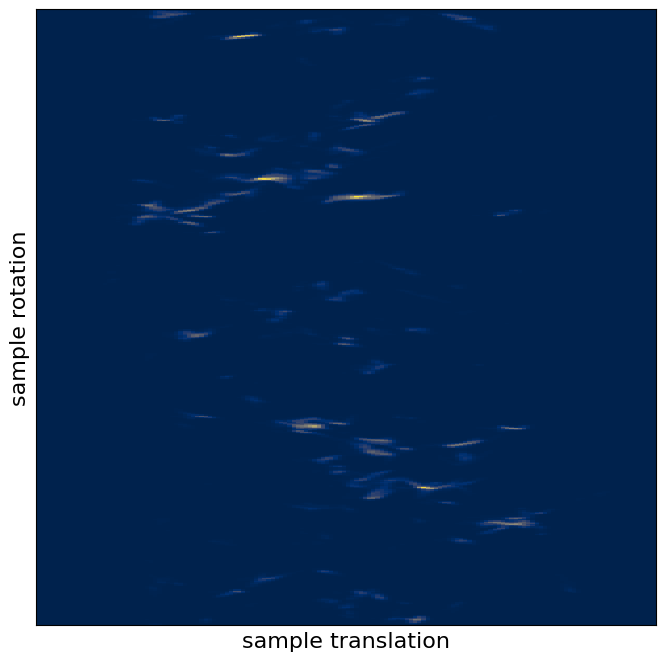

In [10]:
data = all_data_reshaped.reshape((N_rot, Nx, N_chi, N_theta))
plt.figure(figsize=(8,8))
plt.imshow(data[:,:,0:2, 0].mean(axis=(2)), interpolation='nearest', aspect='auto', cmap='cividis')

ax = plt.gca()
ax.set_xticks([])
ax.set_yticks([])

ax.set_xlabel('sample translation', fontsize=16)
ax.set_ylabel('sample rotation', fontsize=16)
plt.savefig(
    '/work3/msaca/presentation_plots/sinogram_single_pixel.png',
    bbox_inches='tight',
    dpi=500
)

In [11]:
cif_folder = Path(cif_path)
filenames = [p.name for p in cif_folder.glob("*.cif")]
N_mat = len(filenames)


path = cif_folder / filenames[0]
material = Material.from_cif(
    cif_path=path,
    wavelength_kev=wavelength_kev,
    min_two_theta=min_two_theta,
    max_two_theta=max_two_theta,
    intensity_cutoff_fraction=reflection_cutoff,
)



grid_resolution_parameter = 34      # example
kernel_sigma = 0.03            # example
sigma_levels = [kernel_sigma]      # start with single level


grid = OrientationTree.from_hopf_fzone(
    material.point_group_matrices,
    grid_resolution_parameter=grid_resolution_parameter,
    sigma_levels=sigma_levels,
)

0.3562848439565492
[0.15253486 0.17618918 0.24949357 0.29284424 0.3858888 ]

=== OpenCL buffer allocation summary ===
coeffs_sino_F                 : shape=(148x500x596),   168.24 MB
coeffs_sino_C                 : shape=(500x148x596),   168.24 MB
_coeffs_batch_F               : shape=(148x148x596),    49.80 MB
_basis_batch_kmax             : shape=(500x596x180x5),  1023.10 MB
_basis_batch_transpose_kmax   : shape=(500x900x596),  1023.10 MB
_grid_inv_kmax                : shape=(596x9),     0.02 MB
_inv_sigma2_kmax              : shape=(596),     0.00 MB
_norm_factor_kmax             : shape=(596),     0.00 MB
---------------------------------------
TOTAL GPU buffer memory:  2432.52 MB



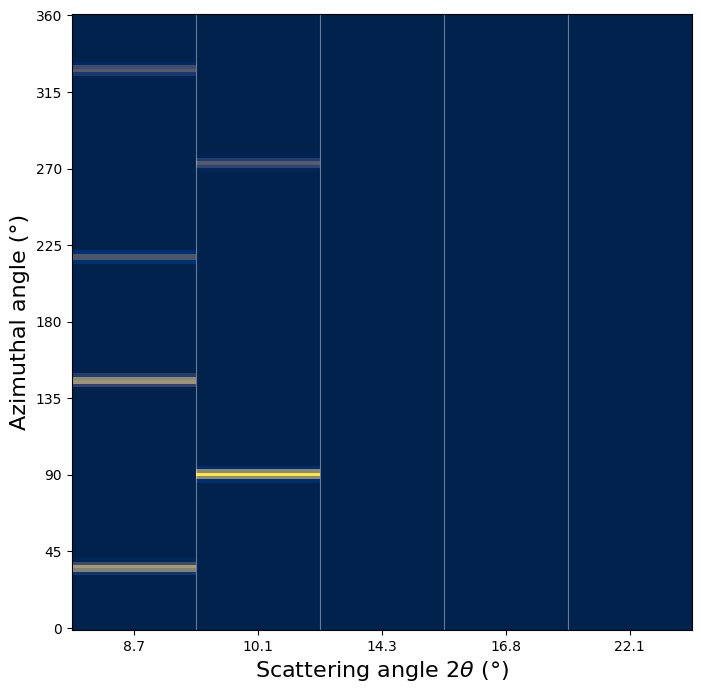

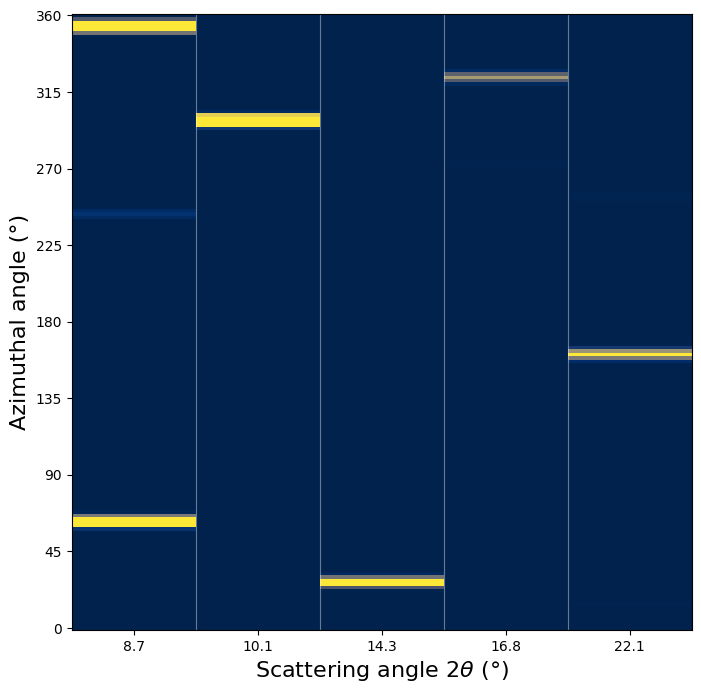

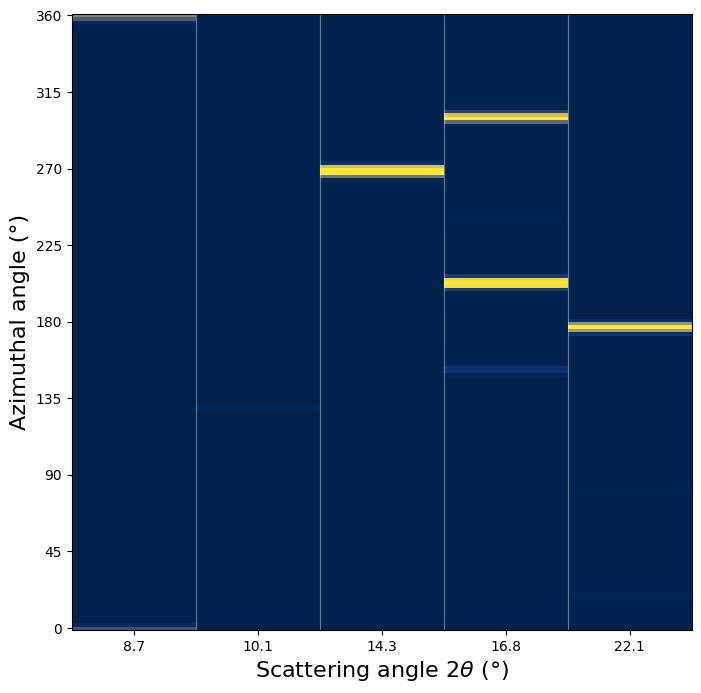

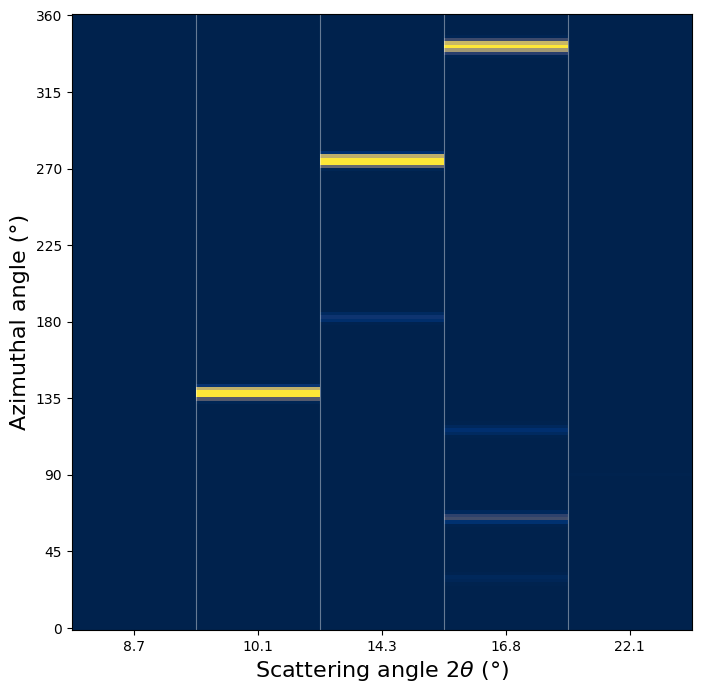

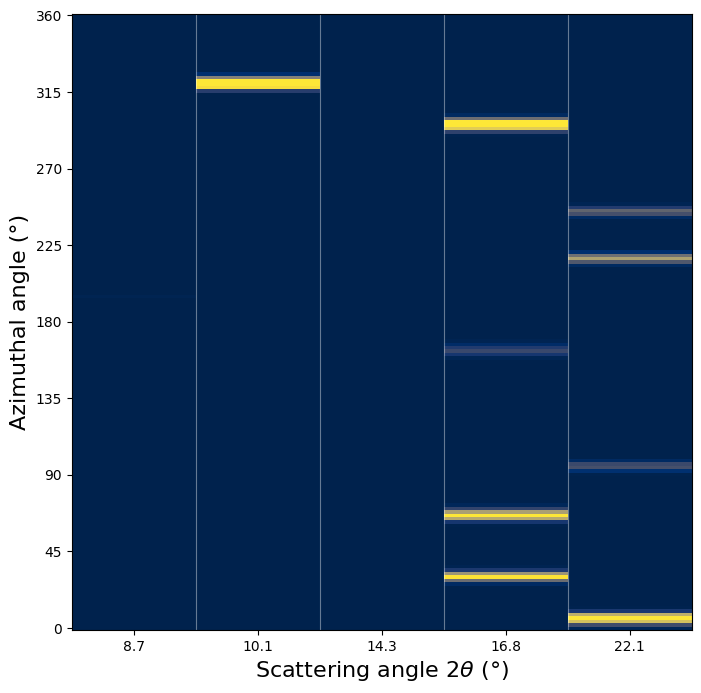

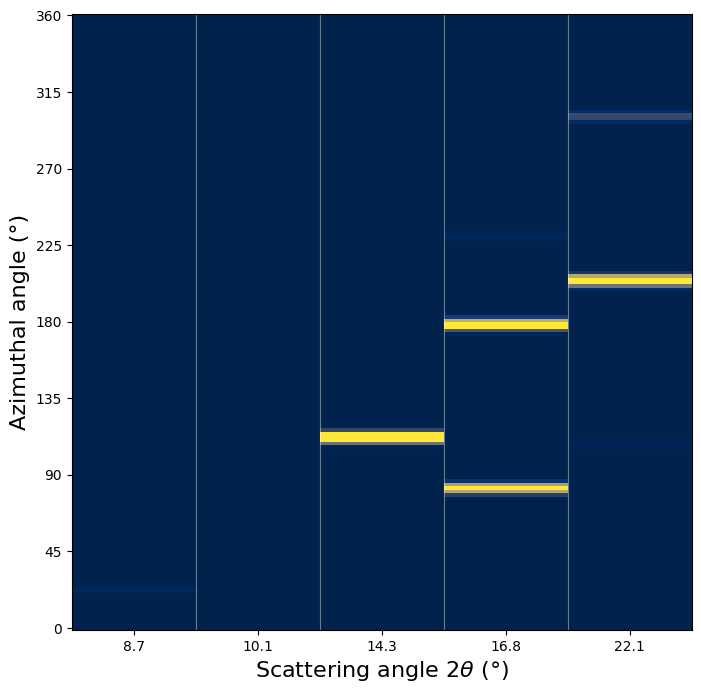

In [12]:
op = PFO_SINGLE(
        cfg = cfg,
        material=material,
        grid=grid,
        max_gb=1.0,
        verbose=True,
        normalized = True,)


queue = op.queue
Nx, Ny, K = op.Nx, op.Ny, op.K


indices = [0, 100, 400, 1200, 2000, 700]
for i in range(len(indices)):
    x_gpu = clarray.zeros(
        queue,
        (Nx, Ny, K),
        dtype=np.float32,
        order="F",
    )

    y_gpu = clarray.zeros(
        queue,
        (N_rot, Nx, N_chi*N_theta),
        dtype=np.float32,
        order="C",
    )

    x_cpu = np.zeros((Nx, Ny, K), order='F')
    x_cpu[:,:,indices[i]] = 1
    x_gpu = clarray.to_device(queue, x_cpu)

    op.direct_cl(x_gpu, y_gpu)
    y_cpu = y_gpu.get()

    prediction = op.direct(x_gpu).get().reshape((N_rot, Nx, N_chi, N_theta))
    coeffs = x_gpu.get().transpose((0,1,2))[::-1,::-1]
    op.free_memory()
    #del x_gpu
    del x_gpu, y_gpu
    gc.collect()

    import numpy as np
    import matplotlib.pyplot as plt

    # given scattering angles (radians)
    theta_rad = np.array([0.15253486, 0.17618918, 0.24949357, 0.29284424, 0.3858888])
    theta_deg = np.degrees(theta_rad)

    data = all_data_reshaped.reshape((N_rot, Nx, N_chi, N_theta))

    fig, ax = plt.subplots(figsize=(8, 8))

    im = ax.imshow(
        prediction[0, 100],
        interpolation='nearest',
        aspect='auto',
        cmap='cividis',
        vmin=0,
        vmax=10000,
        origin='lower'
    )
    for x in np.arange(0.5, nx - 0.5, 1):
        ax.axvline(x, color='white', linewidth=0.8, alpha=0.4)


    # Axis labels
    ax.set_ylabel(r'Azimuthal angle (°)', fontsize=16)
    ax.set_xlabel(r'Scattering angle $2\theta$ (°)', fontsize=16)

    # ----- Y axis: 0 → 360 degrees -----
    ny = data.shape[2]  # N_chi
    ax.set_yticks(np.linspace(0, ny - 1, 9))
    ax.set_yticklabels([f"{v:.0f}" for v in np.linspace(0, 360, 9)])

    # ----- X axis: 5 columns with physical values -----
    nx = data.shape[3]  # N_theta = 5
    ax.set_xticks(np.arange(nx))
    ax.set_xticklabels([f"{v:.1f}" for v in theta_deg])

    plt.savefig(
        '/work3/msaca/presentation_plots/detector_prediction_basis_' + str(i) + '.png',
        bbox_inches='tight',
        dpi=500
    )

In [13]:
with h5py.File('/work3/msaca/textomo_run_013/reconstruction.h5', "r") as f:
    dset = f["x"]
    coeffs = np.empty(dset.shape, dtype=dset.dtype)
    dset.read_direct(coeffs)

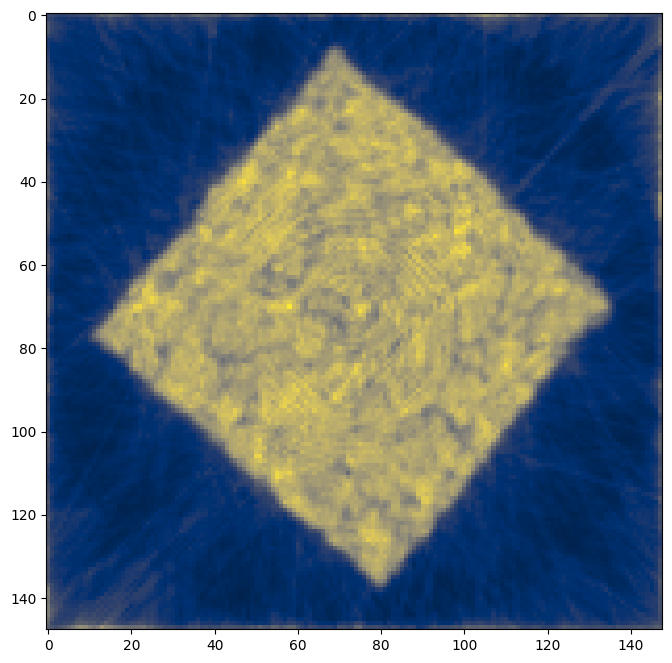

In [14]:
plt.figure(figsize=(8,8))
plt.imshow(coeffs.sum(axis=-1), interpolation='nearest', cmap='cividis')
plt.savefig(
    '/work3/msaca/presentation_plots/summed_recon.png',
    bbox_inches='tight',
    dpi=500
)

In [15]:
with h5py.File("/work3/msaca/basis_set.h5", "r") as f:
    numpy_orien = f["numpy_orien"][...]
    scores = f["scores"][...]



def prune_rotations(Rmats, theta_deg, target=5000):
    # Convert to quaternions
    q = R.from_matrix(Rmats).as_quat()  # (x,y,z,w)
    q /= np.linalg.norm(q, axis=1, keepdims=True)

    # Antipodal equivalence: q and -q represent same rotation
    q_full = np.vstack([q, -q])

    tree = KDTree(q_full)

    theta = np.deg2rad(theta_deg)

    used = np.zeros(len(q_full), dtype=bool)
    keep = []

    for i in range(len(q)):
        if used[i]:
            continue

        keep.append(i)

        # mark neighbors as used
        idx = tree.query_radius(q[i:i+1], r=theta)[0]
        used[idx] = True

        if len(keep) >= target:
            break

    return Rmats[keep]


pruned_orient = prune_rotations(numpy_orien, theta_deg=0.15, target=50000)

grid = OrientationTree.from_rotation_matrices(pruned_orient.transpose((0,2,1)), sigma=0.007)

/tmp/ipykernel_1097500/339480533.py:54: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0)


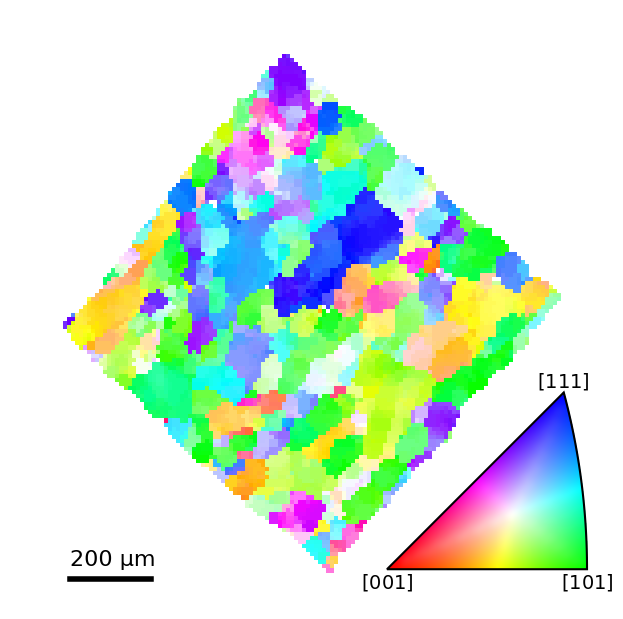

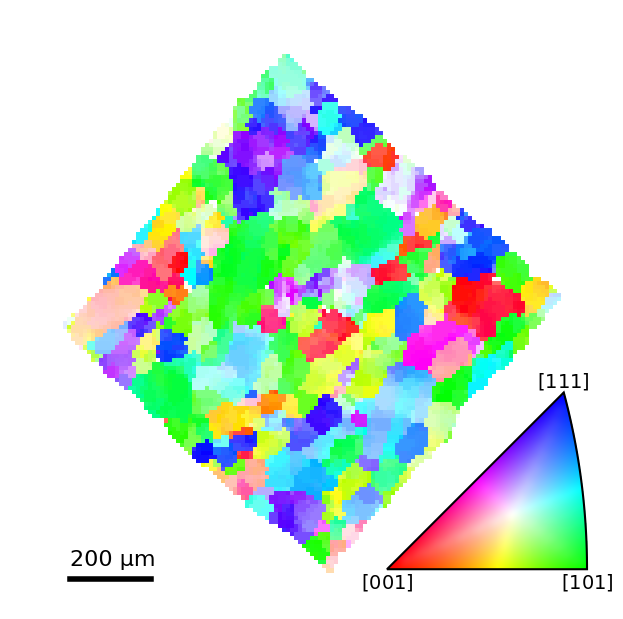

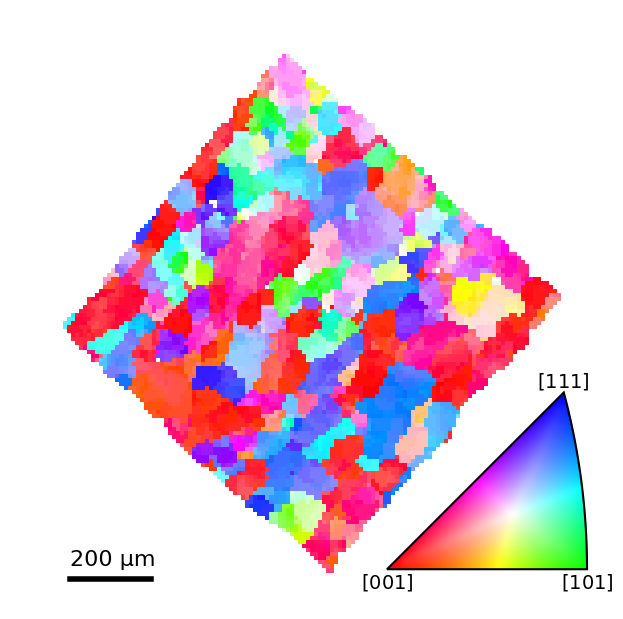

In [29]:
# --- common setup ---
grid_sp = grid.rotations_at_level(0)
grid_sp = R.concatenate(grid_sp)

stepsize = 0.004
extent = (0, coeffs.shape[0]*stepsize,
          coeffs.shape[1]*stepsize, 0)

# mask (computed once)
mask = coeffs.sum(axis=2) > 0.0035
mask[:7] = mask[-7:] = False
mask[:, :7] = mask[:, -7:] = False

# scale bar params
px_um, npx = 10, 20
L = npx * stepsize
x0 = 0.1 * coeffs.shape[0] * stepsize
y0 = 0.95 * coeffs.shape[1] * stepsize


def plot_ipf(direction, outfile):
    ipfkey = plot.IPFColorKeyTSL(
        symmetry.Oh,
        direction=Vector3d(direction)
    )

    orientations = Orientation.from_scipy_rotation(grid_sp)
    orientations.symmetry = ipfkey.symmetry

    rgb = ipfkey.orientation2color(orientations)[
        np.argmax(coeffs, axis=-1)
    ]
    rgb[~mask] = 1.0  # white background

    fig, ax = plt.subplots(figsize=(6, 6), facecolor='white')
    ax.set_facecolor('white')

    ax.imshow(rgb[::-1, ::-1], extent=extent)
    ax.axis('off')

    # scale bar
    ax.plot([x0, x0 + L], [y0, y0], lw=4, color='black')
    ax.text(
        x0, y0 - 0.05 * coeffs.shape[1] * stepsize,
        f"{npx * px_um} µm",
        color='black', ha='left', va='top', fontsize = 16
    )

    ax_ckey = fig.add_axes(
        [0.62, 0.04, 0.35, 0.35], projection="ipf", symmetry=orientations.symmetry, zorder=2
    )
    ax_ckey.plot_ipf_color_key(show_title=False)
    ax_ckey.patch.set_facecolor("None")
    plt.tight_layout(pad=0)
    plt.savefig(outfile, dpi=600)
    plt.show()


# --- generate the three plots ---
plot_ipf([1, 0, 0], '/work3/msaca/textomo_run_009/ipf_x.png')
plot_ipf([0, 1, 0], '/work3/msaca/textomo_run_009/ipf_y.png')
plot_ipf([0, 0, 1], '/work3/msaca/textomo_run_009/ipf_z.png')
